In [1]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# Burned Area Exploration

In [3]:
burned_area = xr.open_mfdataset("data/mcd64a1/burned_fraction_iberia_0p25deg_monthly.nc", combine="by_coords", parallel=True)
burned_area.close()
    
print(burned_area)

<xarray.Dataset> Size: 6MB
Dimensions:          (time: 302, lat: 32, lon: 54)
Coordinates:
  * time             (time) datetime64[ns] 2kB 2000-11-01 ... 2025-12-01
  * lat              (lat) float64 256B 36.25 36.5 36.75 ... 43.5 43.75 44.0
  * lon              (lon) float64 432B -10.0 -9.75 -9.5 -9.25 ... 2.75 3.0 3.25
Data variables:
    burned_fraction  (time, lat, lon) float32 2MB dask.array<chunksize=(302, 32, 54), meta=np.ndarray>
    burned_pixels    (time, lat, lon) int32 2MB dask.array<chunksize=(302, 32, 54), meta=np.ndarray>
    valid_pixels     (time, lat, lon) int32 2MB dask.array<chunksize=(302, 32, 54), meta=np.ndarray>
Attributes:
    title:              MCD64A1 monthly burned fraction, Iberia 0.25° grid
    source:             MODIS MCD64A1 V061 (LP DAAC)
    method:             Pixel-centroid binning from sinusoidal to lon/lat
    burned_definition:  BurnDate > 0
    valid_definition:   BurnDate >= 0 (excludes -1 unmapped, -2 water)


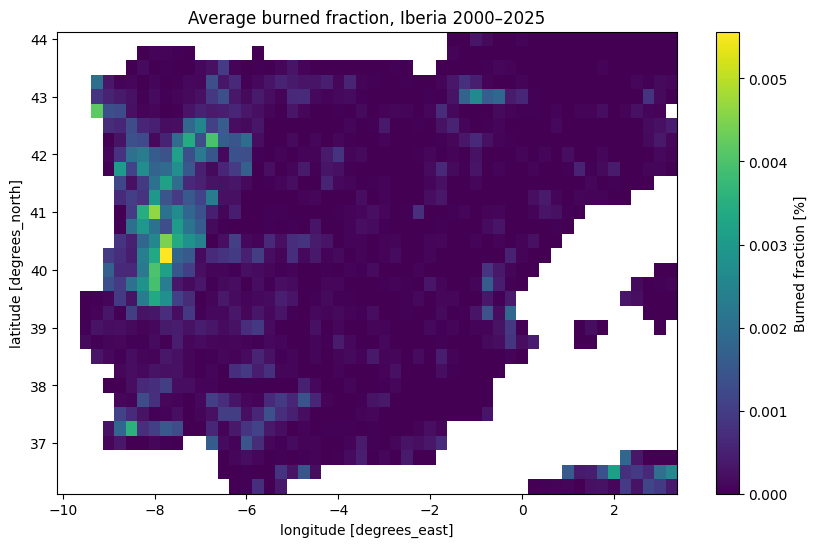

In [8]:
burned_area.burned_fraction.attrs["units"] = "%"

burned_area.burned_fraction.mean(dim="time").plot(figsize=(10, 6))
plt.title("Average burned fraction, Iberia 2000–2025")
plt.show()
